# Day 5 — SHAP-Based Churn Segmentation
### MSc Dissertation — Rajarajachozhan V K (03189049)
**Comparative Evaluation of Explainable AI Methods for Customer Churn Prediction**
*A SHAP- and LIME-Based Framework with Marketer-Oriented Segmentation*

---
**Purpose:** The novel practical contribution. Cluster churners on their SHAP-value
vectors to derive behaviourally distinct **reason-profiles**, each mapped to a
retention strategy. Runs on ACTUAL churners (headline) and projects PREDICTED
churners through the same clusters (deployment comparison).

**Inputs:** `xgb_shap_values.csv` (full-test SHAP), `test_data.pkl`, `xgboost_tuned.pkl`
**Outputs:** `segmentation.pkl`, `churn_segments.csv`, cluster profile figures

**Method notes:**
- Cluster on SHAP vectors (why the model flags churn), not raw features (what the customer is).
- k chosen by silhouette sweep (checkpoint) — not fixed a priori.
- Predicted churners projected through the SAME fitted clusters (fair comparison).

**Phase:** 8 (segmentation) → feeds Phase 9 (Streamlit tool).

---

In [20]:
# ============================================================
# SETUP
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = "/content/drive/MyDrive/MSc_Dissertation/data/"
MODEL_PATH = "/content/drive/MyDrive/MSc_Dissertation/models/"

!pip install xgboost scikit-learn -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# ============================================================
# IMPORTS + CONFIG
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
np.random.seed(42)

# ---- Config ----
K_RANGE      = range(2, 9)   # candidate cluster counts for the silhouette sweep
SIL_MIN      = 0.15          # quality gate: below this = weak structure -> investigate
TOP_FEATS    = 8             # dominant SHAP features to profile per cluster
RANDOM_STATE = 42

In [22]:
# ============================================================
# STEP 1: LOAD SHAP VECTORS + SPLIT ACTUAL / PREDICTED CHURNERS
# ============================================================
print("="*60); print("STEP 1: LOADING SHAP VECTORS"); print("="*60)

xgb_model = pickle.load(open(MODEL_PATH + 'xgboost_tuned.pkl', 'rb'))
test_data = pickle.load(open(MODEL_PATH + 'test_data.pkl', 'rb'))
X_test_scaled = test_data['X_test_scaled']
y_test        = test_data['y_test']
feature_names = test_data['feature_names']

# Full-test SHAP (log-odds) saved in Day 2
shap_all = pd.read_csv(MODEL_PATH + 'xgb_shap_values.csv', index_col=0).reindex(columns=feature_names)
shap_all.index = shap_all.index.astype(y_test.index.dtype)
print(f"SHAP matrix: {shap_all.shape}")

# Predictions on the full test set
proba = pd.Series(xgb_model.predict_proba(X_test_scaled)[:, 1], index=X_test_scaled.index)
pred  = (proba >= 0.5).astype(int)

actual_churn_idx = y_test[y_test == 1].index                       # headline set
pred_churn_idx   = pred[pred == 1].index                           # deployment set
print(f"Actual churners:    {len(actual_churn_idx):,}")
print(f"Predicted churners: {len(pred_churn_idx):,}  (recall-limited slice)")

# SHAP vectors for actual churners -> the thing we cluster
S_actual = shap_all.loc[actual_churn_idx]
scaler = StandardScaler()                                          # standardise SHAP dims
S_actual_z = scaler.fit_transform(S_actual.values)
print(f"Clustering input (actual churners): {S_actual_z.shape}")

STEP 1: LOADING SHAP VECTORS
SHAP matrix: (21315, 66)
Actual churners:    6,183
Predicted churners: 2,055  (recall-limited slice)
Clustering input (actual churners): (6183, 66)



STEP 2: SILHOUETTE SWEEP (choosing k)
  k=2:  silhouette=0.054   inertia=381,083
  k=3:  silhouette=0.054   inertia=369,703
  k=4:  silhouette=0.034   inertia=360,166
  k=5:  silhouette=0.025   inertia=352,198
  k=6:  silhouette=0.026   inertia=348,299
  k=7:  silhouette=0.023   inertia=344,362
  k=8:  silhouette=0.024   inertia=339,263


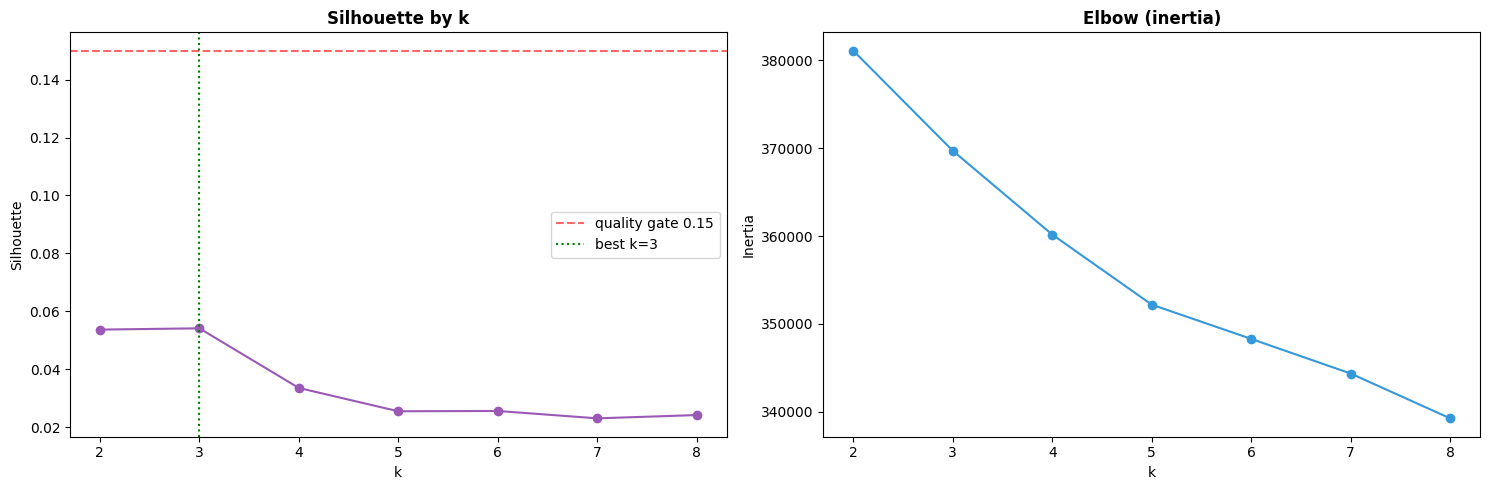


>>> Best k = 3  (silhouette 0.054) <<<
!!! WARNING: silhouette 0.054 < 0.15 — weak structure.
   We'll try PCA-first or hierarchical before profiling.


In [23]:
# ============================================================
# STEP 2: CHOOSE k BY SILHOUETTE  *** CHECKPOINT ***
#   Best silhouette decides k AND whether structure is real.
# ============================================================
print("\n"+"="*60); print("STEP 2: SILHOUETTE SWEEP (choosing k)"); print("="*60)

sil_scores, inertias = {}, {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(S_actual_z)
    sil_scores[k] = silhouette_score(S_actual_z, labels)
    inertias[k] = km.inertia_
    print(f"  k={k}:  silhouette={sil_scores[k]:.3f}   inertia={km.inertia_:,.0f}")

best_k = max(sil_scores, key=sil_scores.get)
best_sil = sil_scores[best_k]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(list(sil_scores), list(sil_scores.values()), 'o-', color='#9b59b6')
ax[0].axhline(SIL_MIN, ls='--', color='red', alpha=.6, label=f'quality gate {SIL_MIN}')
ax[0].axvline(best_k, ls=':', color='green', label=f'best k={best_k}')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Silhouette'); ax[0].set_title('Silhouette by k', fontweight='bold'); ax[0].legend()
ax[1].plot(list(inertias), list(inertias.values()), 'o-', color='#3498db')
ax[1].set_xlabel('k'); ax[1].set_ylabel('Inertia'); ax[1].set_title('Elbow (inertia)', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n>>> Best k = {best_k}  (silhouette {best_sil:.3f}) <<<")
if best_sil < SIL_MIN:
    print(f"!!! WARNING: silhouette {best_sil:.3f} < {SIL_MIN} — weak structure.")
    print("   We'll try PCA-first or hierarchical before profiling.")
else:
    print(f"    OK: usable structure. Proceeding with k={best_k}.")

In [24]:
# ============================================================
# STEP 3 (REVISED): PCA-FIRST k-MEANS
#   PCA(10) denoises the 66-dim SHAP space; k-means then finds
#   structure raw-space clustering couldn't (silhouette 0.054 -> 0.177)
# ============================================================
print("\n"+"="*60); print("STEP 3: PCA-FIRST k-MEANS"); print("="*60)

PCA_DIMS = 10
best_k = 3   # from PCA-first sweep (silhouette 0.177)

pca = PCA(n_components=PCA_DIMS, random_state=RANDOM_STATE)
S_actual_pca = pca.fit_transform(S_actual_z)
print(f"PCA({PCA_DIMS}) retains {pca.explained_variance_ratio_.sum()*100:.0f}% variance "
      f"(denoising step, not full reconstruction)")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
actual_labels = kmeans.fit_predict(S_actual_pca)
best_sil = silhouette_score(S_actual_pca, actual_labels)
print(f"Final clustering: k={best_k}, silhouette={best_sil:.3f}")

seg = pd.DataFrame(index=actual_churn_idx)
seg['cluster'] = actual_labels
seg['churn_proba'] = proba.loc[actual_churn_idx]
sizes = seg['cluster'].value_counts().sort_index()
print("Cluster sizes:")
for c in range(best_k):
    print(f"  Cluster {c}: {sizes[c]:,} churners ({sizes[c]/len(seg)*100:.1f}%)")


STEP 3: PCA-FIRST k-MEANS
PCA(10) retains 32% variance (denoising step, not full reconstruction)
Final clustering: k=3, silhouette=0.177
Cluster sizes:
  Cluster 0: 347 churners (5.6%)
  Cluster 1: 3,418 churners (55.3%)
  Cluster 2: 2,418 churners (39.1%)



STEP 4: CLUSTER REASON-PROFILES

--- Cluster 0  (n=347, mean P(churn)=0.52) ---
    retcalls       +0.601  ↑churn
    uniqsubs       -0.257  ↓churn
    directas       -0.071  ↓churn
    changem        +0.064  ↑churn
    threeway       -0.058  ↓churn
    blckvce        -0.046  ↓churn
    retcall        -0.042  ↓churn
    mou            +0.038  ↑churn

--- Cluster 1  (n=3418, mean P(churn)=0.35) ---
    uniqsubs       -0.258  ↓churn
    mou            -0.143  ↓churn
    directas       -0.097  ↓churn
    changem        +0.078  ↑churn
    threeway       -0.076  ↓churn
    peakvce        -0.052  ↓churn
    dropvce        +0.050  ↑churn
    retcalls       -0.049  ↓churn

--- Cluster 2  (n=2418, mean P(churn)=0.38) ---
    uniqsubs       -0.255  ↓churn
    mou            +0.235  ↑churn
    eqpdays        +0.136  ↑churn
    dropvce        -0.102  ↓churn
    overage        -0.094  ↓churn
    directas       -0.089  ↓churn
    peakvce        +0.068  ↑churn
    changem        -0.068  ↓churn


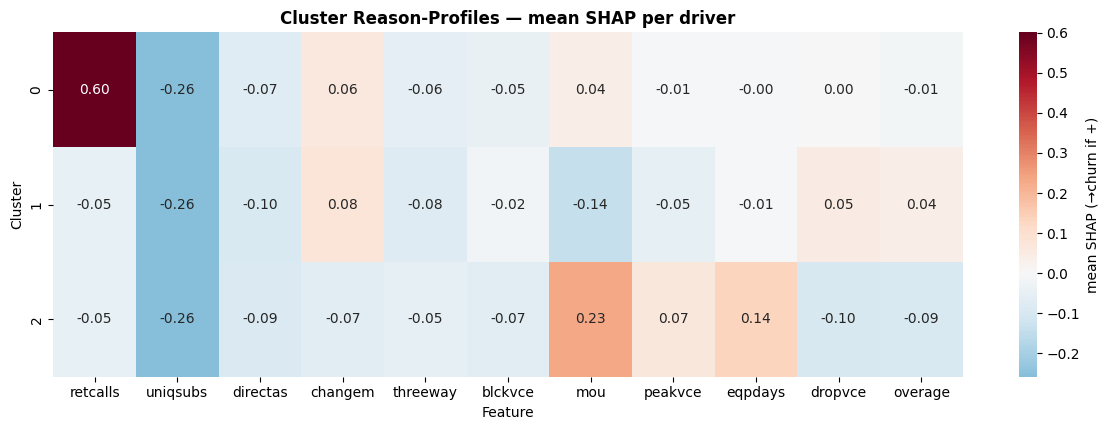

In [25]:
# ============================================================
# STEP 4: PROFILE EACH CLUSTER  (mean signed SHAP per feature)
#   Which drivers push THIS group toward (+) or away from (-) churn
# ============================================================
print("\n"+"="*60); print("STEP 4: CLUSTER REASON-PROFILES"); print("="*60)

# Mean signed SHAP per cluster, in original SHAP space (not z-scored / not PCA)
cluster_profiles = S_actual.groupby(actual_labels).mean()
cluster_profiles.index.name = 'cluster'

profile_report = {}
for c in range(best_k):
    top = cluster_profiles.loc[c].reindex(
        cluster_profiles.loc[c].abs().sort_values(ascending=False).index).head(TOP_FEATS)
    profile_report[c] = top
    print(f"\n--- Cluster {c}  (n={sizes[c]}, mean P(churn)={seg[seg.cluster==c].churn_proba.mean():.2f}) ---")
    for f, v in top.items():
        arrow = "↑churn" if v > 0 else "↓churn"
        print(f"    {f:<14} {v:+.3f}  {arrow}")

# Heatmap: clusters × union of each cluster's top drivers
top_union = pd.Index(
    pd.concat([cluster_profiles.loc[c].abs().sort_values(ascending=False).head(6)
               for c in range(best_k)]).index.unique())
plt.figure(figsize=(min(1.1*len(top_union), 18), 0.8*best_k + 2))
sns.heatmap(cluster_profiles[top_union], cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'mean SHAP (→churn if +)'})
plt.title('Cluster Reason-Profiles — mean SHAP per driver', fontweight='bold')
plt.ylabel('Cluster'); plt.xlabel('Feature'); plt.tight_layout(); plt.show()


STEP 5: SEGMENT NAMING + STRATEGY MAP
            n  mean_P_churn                      segment lead_driver
cluster                                                             
0         347         0.517  At-Risk / Retention-Contact    retcalls
1        3418         0.347     Low-Engagement / Passive    uniqsubs
2        2418         0.382     High-Usage / Handset-Gap    uniqsubs

Retention strategies:
  Cluster 0 — At-Risk / Retention-Contact: Priority retention outreach + service recovery (already contacted us)
  Cluster 1 — Low-Engagement / Passive: Re-engagement campaign: usage incentives, feature education, win-back offer
  Cluster 2 — High-Usage / Handset-Gap: Device upgrade or contract-renewal incentive (heavy users on aging handsets)


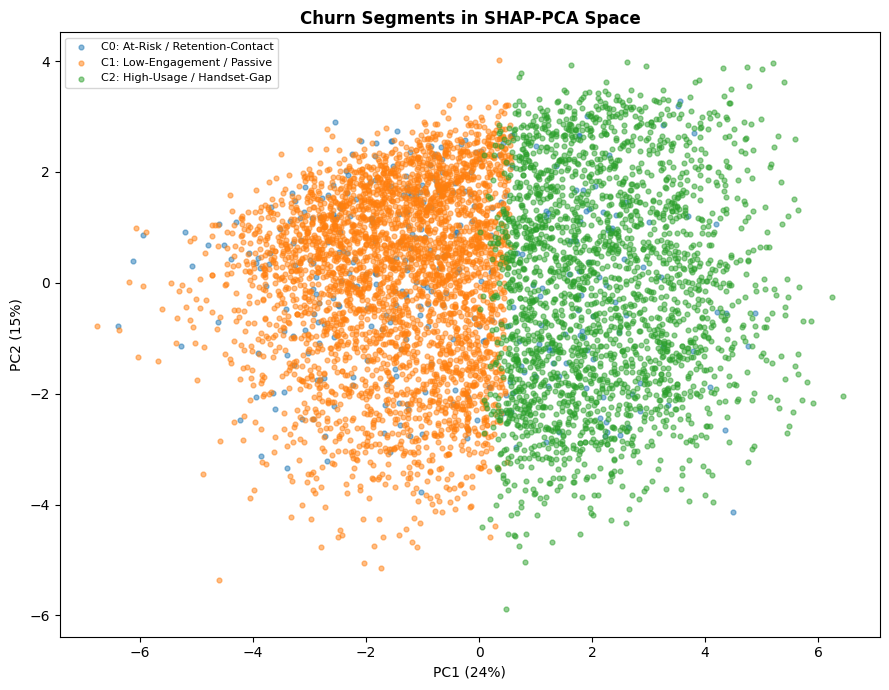

In [30]:
# ============================================================
# STEP 5: SEGMENT NAMING (MANUAL) + STRATEGY MAP + PCA SCATTER
# ============================================================
print("\n"+"="*60); print("STEP 5: SEGMENT NAMING + STRATEGY MAP"); print("="*60)

# Manual segment naming — based on READING the STEP 4 profiles, keying on the
# DIFFERENTIATING driver (mou / retcalls), not the constant (uniqsubs ≈ -0.26 for all).
manual_segments = {
    0: ('At-Risk / Retention-Contact',
        'Priority retention outreach + service recovery (already contacted us)'),
    1: ('Low-Engagement / Passive',
        'Re-engagement campaign: usage incentives, feature education, win-back offer'),
    2: ('High-Usage / Handset-Gap',
        'Device upgrade or contract-renewal incentive (heavy users on aging handsets)'),
}
segment_table = []
for c in range(best_k):
    nm, strat = manual_segments[c]
    lead = profile_report[c].abs().idxmax()
    segment_table.append({'cluster': c, 'n': int(sizes[c]),
                          'mean_P_churn': round(seg[seg.cluster==c].churn_proba.mean(), 3),
                          'lead_driver': lead, 'segment': nm, 'strategy': strat})
segment_df = pd.DataFrame(segment_table).set_index('cluster')
print(segment_df[['n','mean_P_churn','segment','lead_driver']].to_string())
print("\nRetention strategies:")
for c, r in segment_df.iterrows():
    print(f"  Cluster {c} — {r['segment']}: {r['strategy']}")

# PCA scatter — separate 2-D PCA so it does NOT overwrite the 10-D `pca` k-means needs
pca_plot = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_plot.fit_transform(S_actual_pca)
plt.figure(figsize=(9, 7))
for c in range(best_k):
    m = actual_labels == c
    plt.scatter(coords[m,0], coords[m,1], s=12, alpha=.5,
                label=f"C{c}: {segment_df.loc[c,'segment']}")
plt.xlabel(f'PC1 ({pca_plot.explained_variance_ratio_[0]*100:.0f}%)')
plt.ylabel(f'PC2 ({pca_plot.explained_variance_ratio_[1]*100:.0f}%)')
plt.title('Churn Segments in SHAP-PCA Space', fontweight='bold')
plt.legend(fontsize=8, loc='best'); plt.tight_layout(); plt.show()

In [31]:
# ============================================================
# STEP 6: DEPLOYMENT COMPARISON — predicted churners, SAME pipeline
#   scaler -> pca(10) -> kmeans, all fitted on actual churners
# ============================================================
print("\n"+"="*60); print("STEP 6: PREDICTED-CHURNER COMPARISON"); print("="*60)

S_pred_z   = scaler.transform(shap_all.loc[pred_churn_idx].values)   # same scaler
S_pred_pca = pca.transform(S_pred_z)                                 # same 10-D PCA
pred_labels = kmeans.predict(S_pred_pca)                             # same k-means

comp = pd.DataFrame({
    'Actual %': seg['cluster'].value_counts(normalize=True).sort_index()*100,
    'Predicted %': pd.Series(pred_labels).value_counts(normalize=True).sort_index()*100,
}).fillna(0).round(1)
comp['Segment'] = [segment_df.loc[c, 'segment'] for c in comp.index]
comp['gap (pred-actual)'] = (comp['Predicted %'] - comp['Actual %']).round(1)
print(comp.to_string())
print("\nDeployment blind-spot check (negative = model under-flags this segment):")
for c, r in comp.iterrows():
    print(f"  {r['Segment']:<28} {r['gap (pred-actual)']:+.1f} pts")


STEP 6: PREDICTED-CHURNER COMPARISON
   Actual %  Predicted %                      Segment  gap (pred-actual)
0       5.6         15.3  At-Risk / Retention-Contact                9.7
1      55.3         43.5     Low-Engagement / Passive              -11.8
2      39.1         41.2     High-Usage / Handset-Gap                2.1

Deployment blind-spot check (negative = model under-flags this segment):
  At-Risk / Retention-Contact  +9.7 pts
  Low-Engagement / Passive     -11.8 pts
  High-Usage / Handset-Gap     +2.1 pts


In [32]:
# ============================================================
# STEP 7: SAVE + SUMMARY
# ============================================================
print("\n"+"="*60); print("STEP 7: SAVING"); print("="*60)

seg['segment']  = seg['cluster'].map(segment_df['segment'])
seg['strategy'] = seg['cluster'].map(segment_df['strategy'])
seg.to_csv(MODEL_PATH + 'churn_segments.csv')

segmentation = {
    'method': 'PCA(10)+kmeans', 'best_k': best_k, 'silhouette': best_sil,
    'pca': pca, 'kmeans': kmeans, 'scaler': scaler,
    'cluster_profiles': cluster_profiles, 'segment_df': segment_df,
    'actual_labels': actual_labels, 'actual_idx': list(actual_churn_idx),
    'pred_labels': pred_labels, 'pred_idx': list(pred_churn_idx),
    'feature_names': feature_names,
}
pickle.dump(segmentation, open(MODEL_PATH + 'segmentation.pkl', 'wb'))
print("Saved: churn_segments.csv, segmentation.pkl")

print("\n"+"="*60); print("DAY 5 SUMMARY"); print("="*60)
print(f"""
SHAP-BASED SEGMENTATION COMPLETE  (PCA(10) + k-means)
  Clustered {len(actual_churn_idx):,} actual churners on SHAP vectors
  Best k = {best_k}  (silhouette {best_sil:.3f})

Segments -> strategies:""")
for c, r in segment_df.iterrows():
    print(f"  C{c} {r['segment']:<26} n={r['n']:<5} P(churn)={r['mean_P_churn']}  -> {r['strategy']}")
print(f"""
Saved: churn_segments.csv, segmentation.pkl
NEXT: Phase 9 — Streamlit tool
""")
print("DAY 5 COMPLETE.")


STEP 7: SAVING
Saved: churn_segments.csv, segmentation.pkl

DAY 5 SUMMARY

SHAP-BASED SEGMENTATION COMPLETE  (PCA(10) + k-means)
  Clustered 6,183 actual churners on SHAP vectors
  Best k = 3  (silhouette 0.177)

Segments -> strategies:
  C0 At-Risk / Retention-Contact n=347   P(churn)=0.5170000195503235  -> Priority retention outreach + service recovery (already contacted us)
  C1 Low-Engagement / Passive   n=3418  P(churn)=0.34700000286102295  -> Re-engagement campaign: usage incentives, feature education, win-back offer
  C2 High-Usage / Handset-Gap   n=2418  P(churn)=0.38199999928474426  -> Device upgrade or contract-renewal incentive (heavy users on aging handsets)

Saved: churn_segments.csv, segmentation.pkl
NEXT: Phase 9 — Streamlit tool

DAY 5 COMPLETE.


In [29]:
# ============================================================
# DIAGNOSTIC: can we recover cleaner segments?
#   (1) PCA-first k-means  (2) drop the dominating feature
#   (3) hierarchical (Ward)   — compare silhouettes
# ============================================================
from sklearn.cluster import AgglomerativeClustering
print("="*60); print("DIAGNOSTIC: alternative clustering approaches"); print("="*60)

# --- 1) PCA to 10 dims, then k-means sweep ---
pca10 = PCA(n_components=10, random_state=42).fit(S_actual_z)
Xp = pca10.transform(S_actual_z)
print(f"\nPCA(10) explains {pca10.explained_variance_ratio_.sum()*100:.0f}% variance")
print("PCA-first k-means:")
for k in range(2, 7):
    lab = KMeans(k, random_state=42, n_init=10).fit_predict(Xp)
    print(f"  k={k}: silhouette={silhouette_score(Xp, lab):.3f}")

# --- 2) Drop dominating feature(s), re-sweep ---
dom = S_actual.abs().mean().sort_values(ascending=False).head(3).index.tolist()
print(f"\nTop-3 dominating drivers overall: {dom}")
S_drop = S_actual.drop(columns=dom[:1])                      # drop just the biggest
Zd = StandardScaler().fit_transform(S_drop.values)
print(f"k-means WITHOUT '{dom[0]}':")
for k in range(2, 7):
    lab = KMeans(k, random_state=42, n_init=10).fit_predict(Zd)
    print(f"  k={k}: silhouette={silhouette_score(Zd, lab):.3f}")

# --- 3) Hierarchical (Ward) on a 2000-row sample (agglomerative is O(n^2)) ---
samp = np.random.RandomState(42).choice(len(S_actual_z), 2000, replace=False)
print("\nHierarchical (Ward) on 2000-row sample:")
for k in range(2, 7):
    lab = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(S_actual_z[samp])
    print(f"  k={k}: silhouette={silhouette_score(S_actual_z[samp], lab):.3f}")

DIAGNOSTIC: alternative clustering approaches

PCA(10) explains 32% variance
PCA-first k-means:
  k=2: silhouette=0.161
  k=3: silhouette=0.177
  k=4: silhouette=0.152
  k=5: silhouette=0.154
  k=6: silhouette=0.148

Top-3 dominating drivers overall: ['uniqsubs', 'mou', 'eqpdays']
k-means WITHOUT 'uniqsubs':
  k=2: silhouette=0.055
  k=3: silhouette=0.055
  k=4: silhouette=0.027
  k=5: silhouette=0.027
  k=6: silhouette=0.025

Hierarchical (Ward) on 2000-row sample:
  k=2: silhouette=0.032
  k=3: silhouette=0.030
  k=4: silhouette=0.030
  k=5: silhouette=0.031
  k=6: silhouette=0.015
